# SECTION 1: Data exploration and pre-processing

In [1]:
#install required packages --- IGNORE ---
#!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
#import libraries --- IGNORE ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib as jl

Load of the database of ssh attacks.

In [3]:
# -----------------------
# LOAD THE DATA
# -----------------------
df = pd.read_parquet("ssh_attacks.parquet")
jl.dump(df,'df.pkl')
print("DataFrame salvato con successo!") #to see if joblib does its work
print(df.head())

DataFrame salvato con successo!
   session_id                                       full_session  \
0           0  enable ; system ; shell ; sh ; cat /proc/mount...   
1           1  enable ; system ; shell ; sh ; cat /proc/mount...   
2           2  enable ; system ; shell ; sh ; cat /proc/mount...   
3           3  enable ; system ; shell ; sh ; cat /proc/mount...   
4           4  enable ; system ; shell ; sh ; cat /proc/mount...   

                    first_timestamp               Set_Fingerprint  
0  2019-06-04 09:45:11.151186+00:00  [Defense Evasion, Discovery]  
1  2019-06-04 09:45:50.396610+00:00  [Defense Evasion, Discovery]  
2  2019-06-04 09:54:41.863315+00:00  [Defense Evasion, Discovery]  
3  2019-06-04 10:22:14.623875+00:00  [Defense Evasion, Discovery]  
4  2019-06-04 10:37:19.725874+00:00  [Defense Evasion, Discovery]  


### 1. Analisys of temporal series.


--- 1. Temporal Analysis of Attacks ---


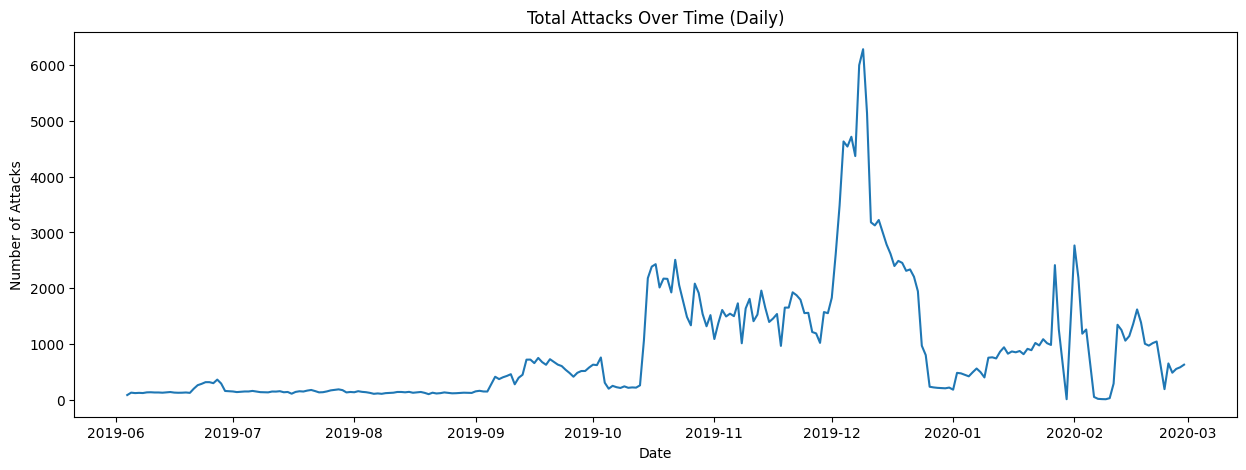

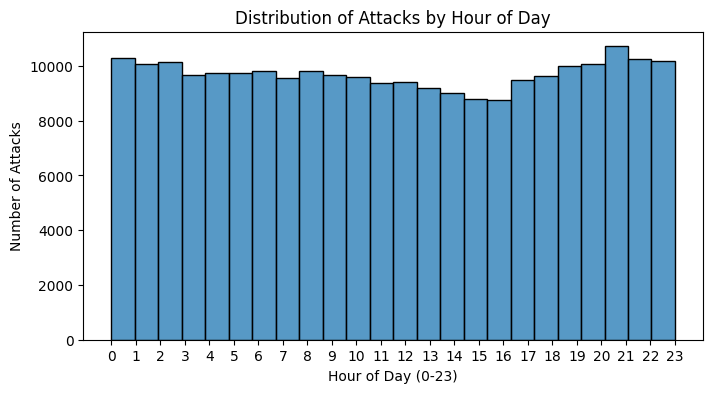

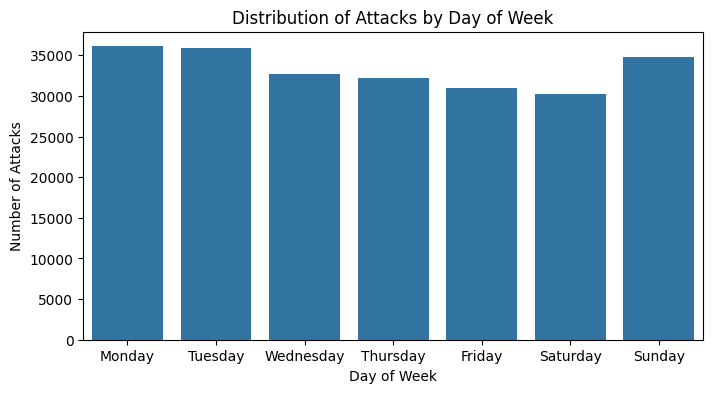

In [4]:
## Question 1: Temporal Analysis
print("\n--- 1. Temporal Analysis of Attacks ---")

if not df.empty and 'first_timestamp' in df.columns:
    # Ensure the column is of datetime type
    df['first_timestamp'] = pd.to_datetime(df['first_timestamp'])

    # Extract temporal components
    df['date'] = df['first_timestamp'].dt.date
    df['hour'] = df['first_timestamp'].dt.hour
    df['day_of_week'] = df['first_timestamp'].dt.dayofweek  # Monday=0, Sunday=6

    # 1. Time series plot (Attacks per day)
    attacks_per_day = df.groupby('date').size()
    plt.figure(figsize=(15, 5))
    attacks_per_day.plot()
    plt.title('Total Attacks Over Time (Daily)')
    plt.xlabel('Date')
    plt.ylabel('Number of Attacks')
    plt.show()

    # 2. Distribution plot by hour of the day
    plt.figure(figsize=(8, 4))
    sns.histplot(df['hour'], bins=24, kde=False)
    plt.title('Distribution of Attacks by Hour of Day')
    plt.xlabel('Hour of Day (0-23)')
    plt.ylabel('Number of Attacks')
    plt.xticks(range(0, 24))
    plt.show()

    # 3. Distribution plot by day of the week
    days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    attacks_per_weekday = df.groupby('day_of_week').size().reindex(range(7), fill_value=0)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=attacks_per_weekday.index, y=attacks_per_weekday.values)
    plt.title('Distribution of Attacks by Day of Week')
    plt.xlabel('Day of Week')
    plt.ylabel('Number of Attacks')
    plt.xticks(ticks=range(7), labels=days, rotation=0)
    plt.show()
else:
    print("Unable to perform temporal analysis.")


### 2. Distribution of the number of characters and words per full sessions text attack

=== CHARACTER COUNTS ===
count    233035.000000
mean       1013.865119
std        2282.583441
min           3.000000
25%         614.000000
50%         620.000000
75%        1415.000000
max      203442.000000
Name: n_chars, dtype: float64

Unique character lengths: 790

=== WORD COUNTS ===
count    233035.000000
mean        120.801399
std          87.692157
min           2.000000
25%         116.000000
50%         116.000000
75%         138.000000
max       34404.000000
Name: n_words, dtype: float64

Unique word counts: 250


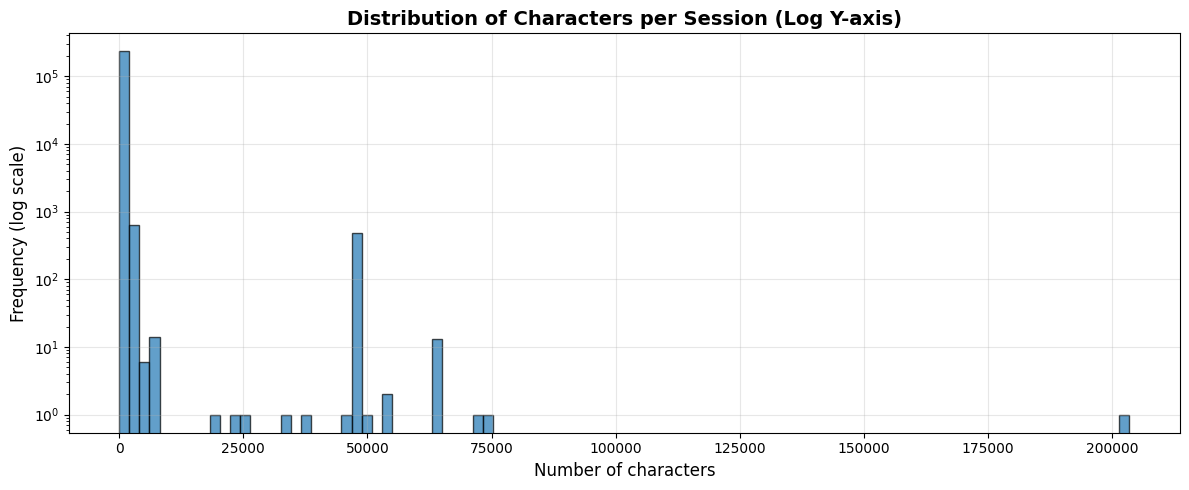

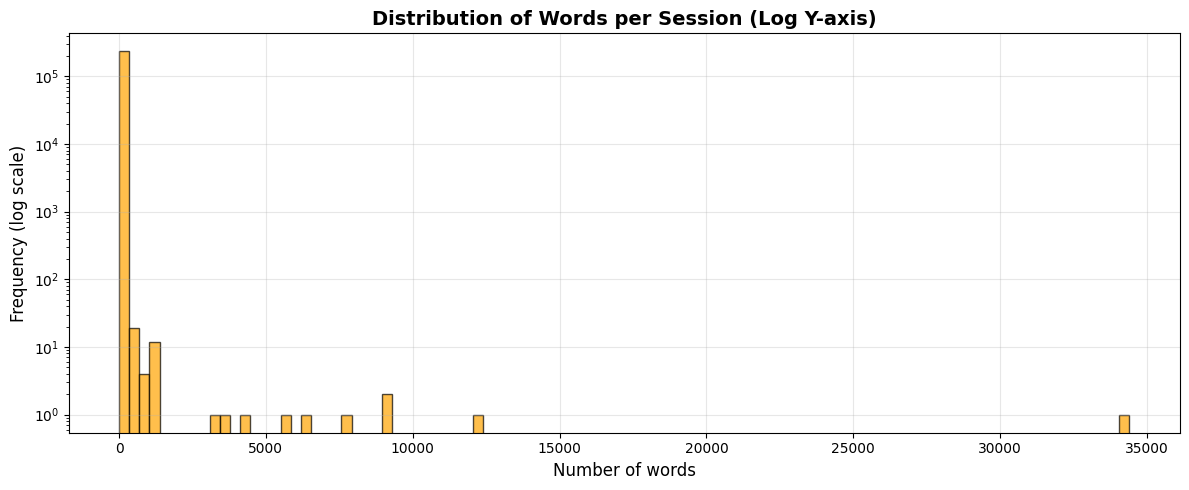

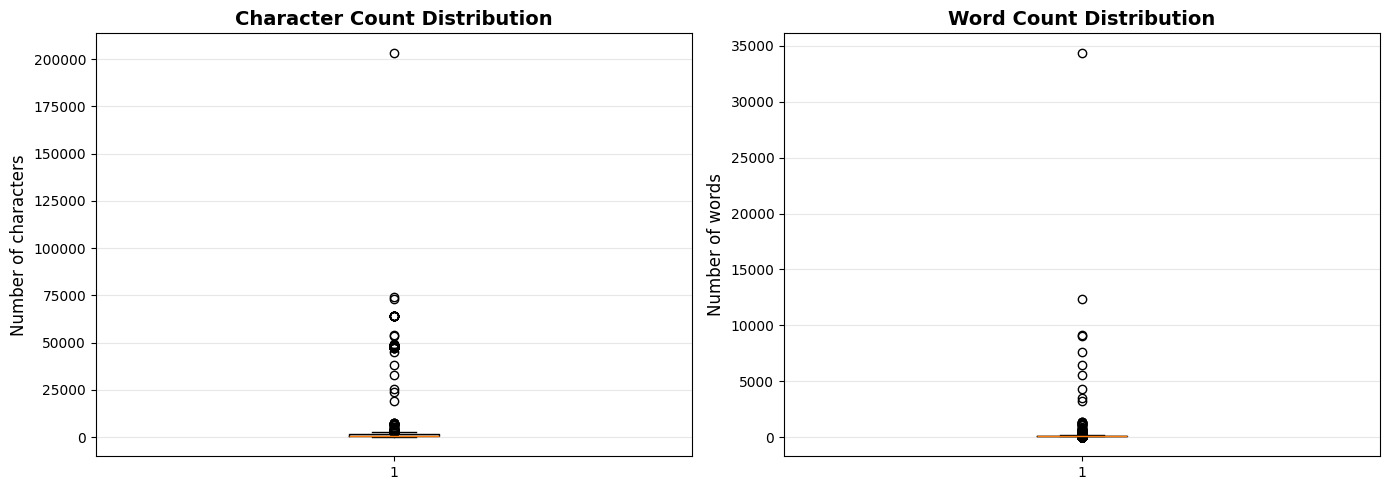

In [5]:
# -----------------------
# FEATURE EXTRACTION
# -----------------------

# Convert to string and handle any NaN values
session_str = df['full_session'].astype(str)

# 1. Number of characters in each session (vectorized)
df['n_chars'] = session_str.apply(len)

# 2. Number of words in each session (vectorized)
df['n_words'] = session_str.str.split().apply(len)

# -----------------------
# SUMMARY STATISTICS
# -----------------------
print("=== CHARACTER COUNTS ===")
print(df['n_chars'].describe())
print("\nUnique character lengths:", df['n_chars'].nunique())

print("\n=== WORD COUNTS ===")
print(df['n_words'].describe())
print("\nUnique word counts:", df['n_words'].nunique())


# -----------------------
# HISTOGRAMS - LOG SCALE (Better for skewed data)
# -----------------------

# Character distribution - log scale on y-axis only
plt.figure(figsize=(12,5))
plt.hist(df['n_chars'], bins=100, edgecolor='black', alpha=0.7)
plt.yscale('log')
plt.title("Distribution of Characters per Session (Log Y-axis)", fontsize=14, fontweight='bold')
plt.xlabel("Number of characters", fontsize=12)
plt.ylabel("Frequency (log scale)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Word distribution - log scale on y-axis only
plt.figure(figsize=(12,5))
plt.hist(df['n_words'], bins=100, edgecolor='black', alpha=0.7, color='orange')
plt.yscale('log')
plt.title("Distribution of Words per Session (Log Y-axis)", fontsize=14, fontweight='bold')
plt.xlabel("Number of words", fontsize=12)
plt.ylabel("Frequency (log scale)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------
# BOX PLOTS (Alternative view to see quartiles and outliers)
# -----------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character count boxplot
axes[0].boxplot(df['n_chars'], vert=True)
axes[0].set_ylabel('Number of characters', fontsize=12)
axes[0].set_title('Character Count Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Word count boxplot
axes[1].boxplot(df['n_words'], vert=True)
axes[1].set_ylabel('Number of words', fontsize=12)
axes[1].set_title('Word Count Distribution', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Exercise 3

### 3. Most common words analysis.

=== TOP 30 MOST COMMON WORDS (cleaned tokens) ===
Rank   Word                                          Count Percentage
----------------------------------------------------------------------
1      grep                                      1,278,484      6.78%
2      cat                                       1,082,651      5.75%
3      echo                                        957,748      5.08%
4      -l                                          640,285      3.40%
5      uname                                       639,136      3.39%
6      /proc/cpuinfo                               638,865      3.39%
7      name                                        638,772      3.39%
8      /var/tmp/.var03522123                       637,129      3.38%
9      rm                                          451,423      2.40%
10     -rf                                         429,957      2.28%
11     awk                                         426,372      2.26%
12     'print                          

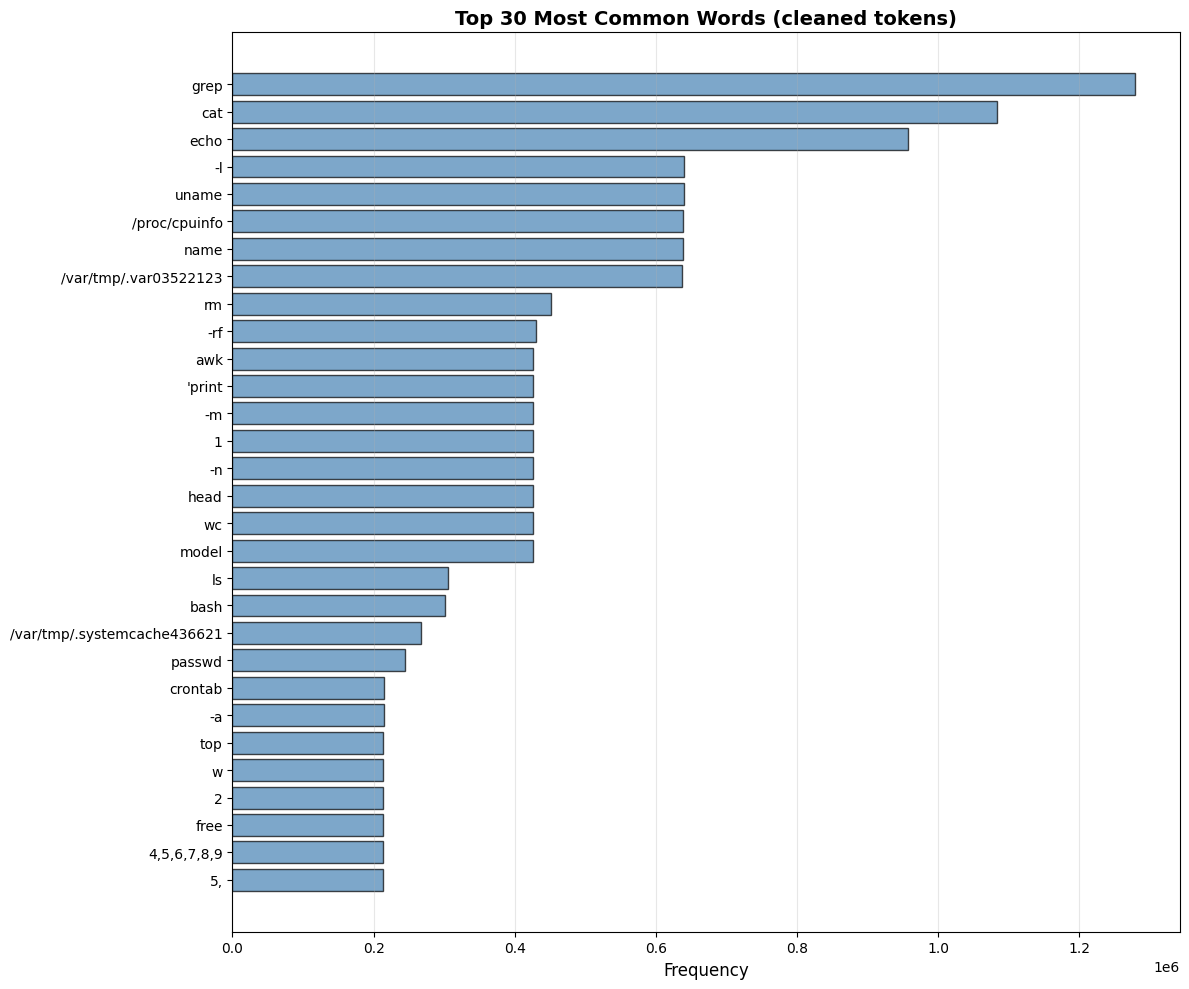

In [6]:
# -----------------------
# MOST COMMON WORDS ANALYSIS (using sklearn)
# -----------------------

from sklearn.feature_extraction.text import CountVectorizer
import re

# Preprocessing function: remove {, }, -, $ from tokens while keeping /
def clean_token(text):
    # Remove unwanted characters from each token
    text = text.replace('$', '').replace("'{}", '')
    text = text.replace('{', '').replace('}', '')
    return text

# Apply cleaning to all sessions
cleaned_sessions = df['full_session'].astype(str).apply(clean_token)

# Define custom stop words - remove punctuation and operators
custom_stop_words = [';', '||', '&&', '|', '>', '<', '(', ')', '[', ']', 
                     ',', '.', '!', '?', ':', '=', '+', '*', '\\',
                     '`', '~', '@', '#', '%', '^', '&', '"', "'"]

# Create CountVectorizer
# - token_pattern=r'\S+' : splits on whitespace (keeps / in paths)
# - stop_words : removes punctuation and operators from counting
vectorizer = CountVectorizer(
    token_pattern=r'\S+',
    stop_words=custom_stop_words,
    max_features=None
)

# Fit and transform the cleaned sessions
X = vectorizer.fit_transform(cleaned_sessions)

# Get vocabulary and word counts
vocabulary = vectorizer.get_feature_names_out()
word_counts = X.sum(axis=0).A1  # Sum across all documents

# Create a sorted list of (word, count) tuples
word_count_pairs = list(zip(vocabulary, word_counts))
word_count_pairs.sort(key=lambda x: x[1], reverse=True)

# Get top 30
top_30_words = word_count_pairs[:30]

print("=== TOP 30 MOST COMMON WORDS (cleaned tokens) ===")
print(f"{'Rank':<6} {'Word':<40} {'Count':>10} {'Percentage':>10}")
print("-" * 70)
total_words = word_counts.sum()
for i, (word, count) in enumerate(top_30_words, 1):
    percentage = (count / total_words) * 100
    print(f"{i:<6} {word:<40} {int(count):>10,} {percentage:>9.2f}%")

print(f"\nTotal unique words (vocabulary size): {len(vocabulary):,}")
print(f"Total word occurrences: {int(total_words):,}")

# -----------------------
# VISUALIZATION OF TOP WORDS
# -----------------------

# Extract words and counts for plotting
words = [word for word, count in top_30_words]
counts = [count for word, count in top_30_words]

# Horizontal bar chart (better for long words/paths)
plt.figure(figsize=(12, 10))
plt.barh(range(len(words)), counts, color='steelblue', edgecolor='black', alpha=0.7)
plt.yticks(range(len(words)), words, fontsize=10)
plt.xlabel('Frequency', fontsize=12)
plt.title('Top 30 Most Common Words (cleaned tokens)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Most common at top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 4. Intent Analysis (Set_Fingerprint)

=== INTENT DISTRIBUTION ANALYSIS ===

--- Intents per Session ---
count    233035.000000
mean          2.394173
std           0.523645
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max           7.000000
Name: n_intents, dtype: float64

Most common number of intents per session:
n_intents
2    136458
3     92571
1      2928
4      1025
5        50
6         2
7         1
Name: count, dtype: int64


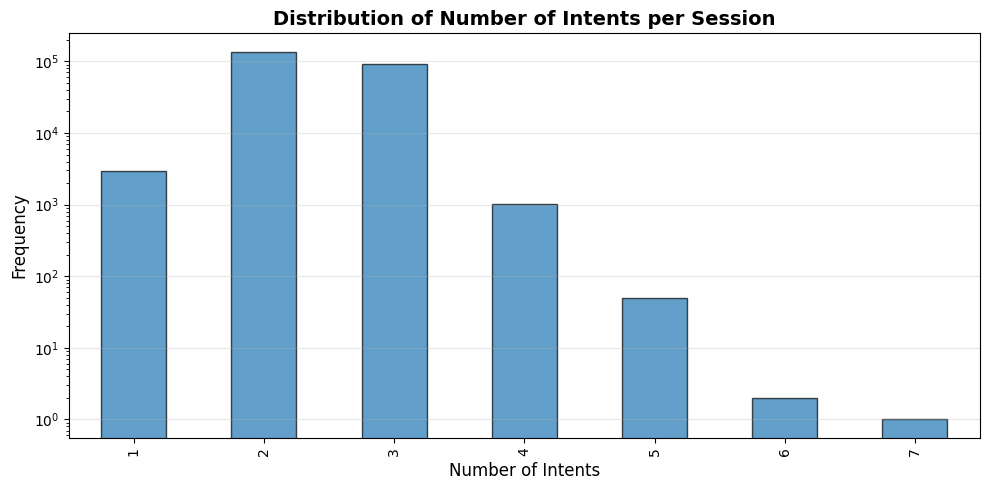


--- Top 10 Most Common Intents ---
Rank   Intent                                        Count Percentage
----------------------------------------------------------------------
1      Discovery                                   232,145     41.61%
2      Persistence                                 211,295     37.87%
3      Execution                                    92,927     16.66%
4      Defense Evasion                              18,999      3.41%
5      Harmless                                      2,206      0.40%
6      Other                                           327      0.06%
7      Impact                                           27      0.00%


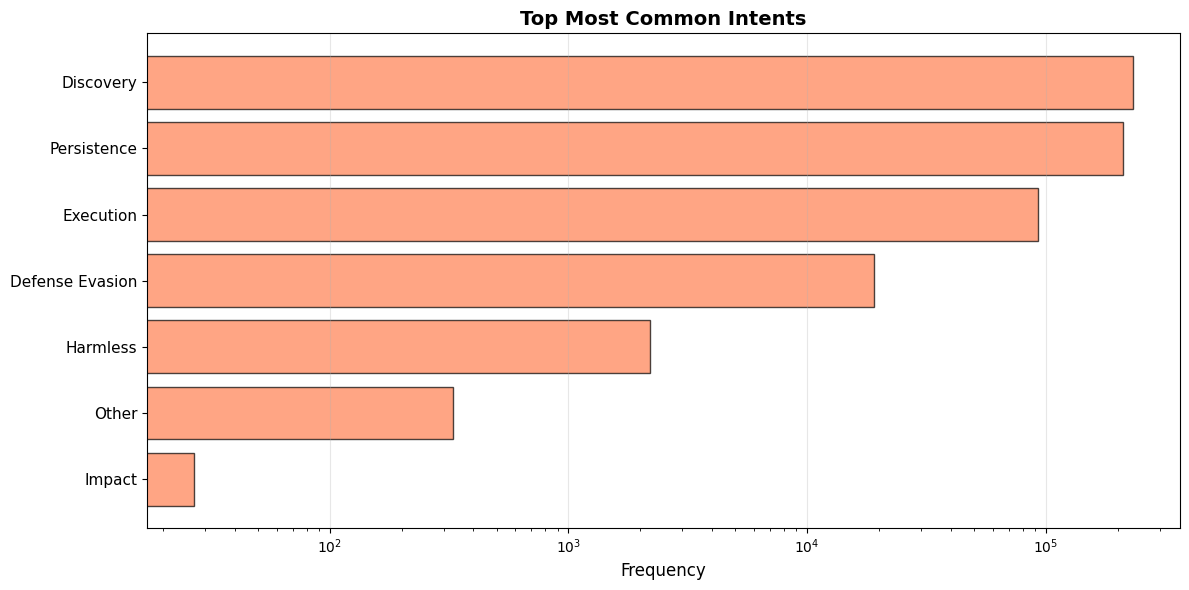


--- Top 10 Most Common Intent Combinations ---
Rank   Intent Combination                                                Count
--------------------------------------------------------------------------------
1      ['Discovery', 'Persistence']                                    117,951
2      ['Discovery', 'Execution', 'Persistence']                        90,510
3      ['Defense Evasion', 'Discovery']                                 17,909
4      ['Discovery']                                                     2,237
5      ['Discovery', 'Harmless', 'Persistence']                          1,693
6      ['Defense Evasion', 'Discovery', 'Execution', 'Persistence']        512
7      ['Execution']                                                       453
8      ['Discovery', 'Execution']                                          398
9      ['Discovery', 'Execution', 'Other', 'Persistence']                  301
10     ['Defense Evasion', 'Discovery', 'Execution']                       291

-

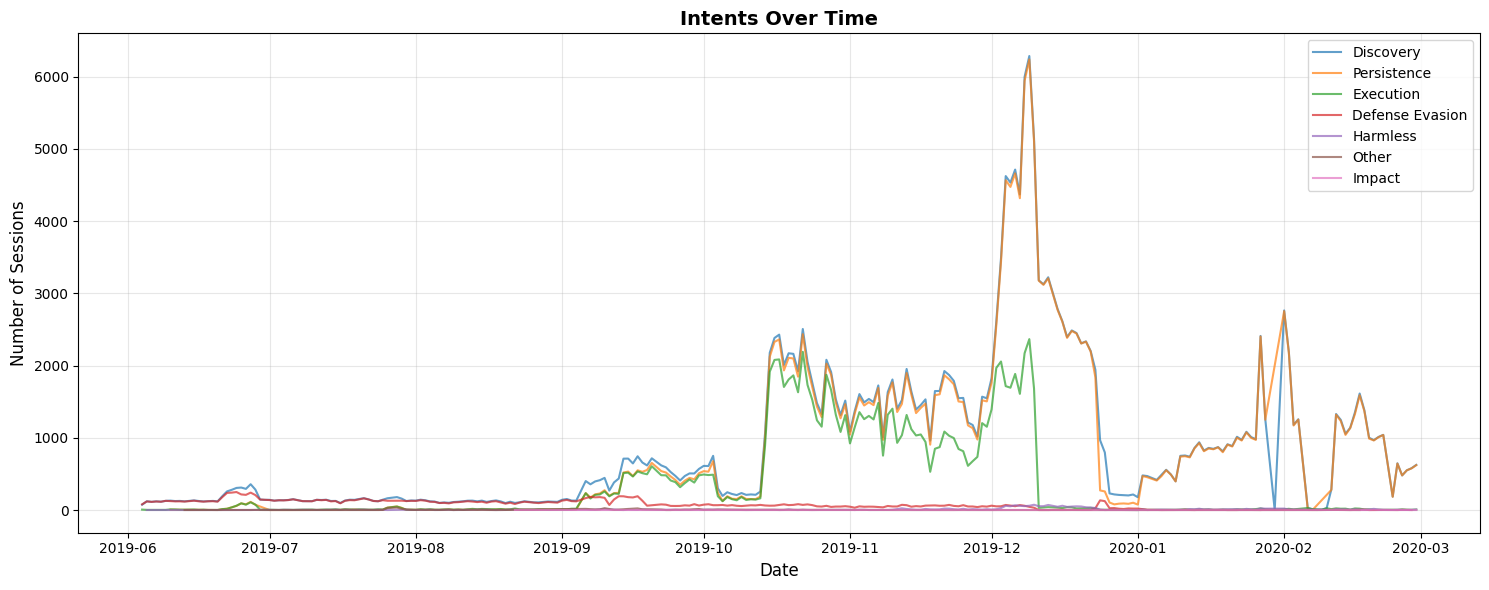


Intent analysis complete!


In [7]:
# -----------------------
# INTENT ANALYSIS
# -----------------------

import ast
from collections import Counter

print("=== INTENT DISTRIBUTION ANALYSIS ===\n")

# Parse Set_Fingerprint (stored as string representation of list)
df['fingerprint_list'] = df['Set_Fingerprint'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
jl.dump(df['fingerprint_list'], "df_fingerprint_list.pkl") #to use in other notebooks

# 1. Number of intents per session
df['n_intents'] = df['fingerprint_list'].apply(len)

print("--- Intents per Session ---")
print(df['n_intents'].describe())
print(f"\nMost common number of intents per session:")
print(df['n_intents'].value_counts().head(10))

# Visualization: Distribution of number of intents per session
plt.figure(figsize=(10, 5))
df['n_intents'].value_counts().sort_index().plot(kind='bar', edgecolor='black', alpha=0.7)
plt.title('Distribution of Number of Intents per Session', fontsize=14, fontweight='bold')
plt.xlabel('Number of Intents', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.yscale('log')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Most common individual intents
all_intents = []
for intent_list in df['fingerprint_list']:
    all_intents.extend(intent_list)

intent_counts = Counter(all_intents)
top_10_intents = intent_counts.most_common(10)

print("\n--- Top 10 Most Common Intents ---")
print(f"{'Rank':<6} {'Intent':<40} {'Count':>10} {'Percentage':>10}")
print("-" * 70)
total_intents = len(all_intents)
for i, (intent, count) in enumerate(top_10_intents, 1):
    percentage = (count / total_intents) * 100
    print(f"{i:<6} {intent:<40} {count:>10,} {percentage:>9.2f}%")

# Visualization: Top 10 intents
intents = [intent for intent, count in top_10_intents]
counts = [count for intent, count in top_10_intents]

plt.figure(figsize=(12, 6))
plt.barh(range(len(intents)), counts, color='coral', edgecolor='black', alpha=0.7)
plt.yticks(range(len(intents)), intents, fontsize=11)
plt.xlabel('Frequency', fontsize=12)
plt.xscale('log')
plt.title('Top Most Common Intents', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Most common intent combinations (fingerprint sets)
fingerprint_str = df['fingerprint_list'].apply(lambda x: str(sorted(x)))
top_10_combinations = fingerprint_str.value_counts().head(10)

print("\n--- Top 10 Most Common Intent Combinations ---")
print(f"{'Rank':<6} {'Intent Combination':<60} {'Count':>10}")
print("-" * 80)
for i, (combo, count) in enumerate(top_10_combinations.items(), 1):
    print(f"{i:<6} {combo:<60} {count:>10,}")

# 4. Intent distribution over time
print("\n--- Intent Distribution Over Time ---")

# Ensure timestamp is datetime
df['first_timestamp'] = pd.to_datetime(df['first_timestamp'])
df['date'] = df['first_timestamp'].dt.date

# Count top 5 intents per day
intent_names = [intent for intent, _ in top_10_intents[:7]]

# Create a matrix: date x intent
intent_time_data = []
for intent_name in intent_names:
    df[f'has_{intent_name}'] = df['fingerprint_list'].apply(lambda x: intent_name in x)
    daily_counts = df[df[f'has_{intent_name}']].groupby('date').size()
    intent_time_data.append(daily_counts)

# Plot time series for top 5 intents
plt.figure(figsize=(15, 6))
for i, intent_name in enumerate(intent_names):
    intent_time_data[i].plot(label=intent_name, alpha=0.7)
plt.title('Intents Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nIntent analysis complete!")

### 5. Numerical Representation (Bag of Words)

In [8]:
## SECTION 1 - Point 5: Numerical Representation (Bag of Words)

print("\n--- 5. Numerical Representation: Bag of Words (BoW) ---")

if 'df' in locals() and not df.empty and 'full_session' in df.columns:
    
    # 1. PREPROCESSING
    # ---------------------------------------------------------
    # Define the cleaning function (same as Point 3)
    def clean_token(text):
        if not isinstance(text, str): return str(text)
        # Remove specific characters but keep the structure
        text = text.replace('$', '').replace("'{}", '')
        text = text.replace('{', '').replace('}', '')
        return text

    print("Applying text cleaning...")
    # Apply the cleaning function to the sessions
    cleaned_sessions = df['full_session'].astype(str).apply(clean_token)

    # Define custom stop words (same as Point 3)
    # Removing shell operators and punctuation that don't add semantic meaning for intent
    custom_stop_words = [';', '||', '&&', '|', '>', '<', '(', ')', '[', ']', 
                         ',', '.', '!', '?', ':', '=', '+', '*', '\\',
                         '`', '~', '@', '#', '%', '^', '&', '"', "'"]

    # 2. BAG OF WORDS (BoW) TRANSFORMATION
    # ---------------------------------------------------------
    print("Generating Bag of Words matrix...")
    
    # Initialize CountVectorizer with the same settings as Point 3
    # token_pattern=r'\S+' splits on whitespace only, preserving paths like /bin/sh
    # max_features=1000 limits the vector size to the top 1000 most frequent words to save RAM
    bow_vectorizer = CountVectorizer(
        token_pattern=r'\S+', 
        stop_words=custom_stop_words,
        max_features=1000 
    )
    
    # Fit and transform the data to create the matrix
    X_bow = bow_vectorizer.fit_transform(cleaned_sessions)
    
    # 3. OUTPUT AND ANALYSIS
    # ---------------------------------------------------------
    print(f"\nBoW Matrix Shape: {X_bow.shape}")
    print("(Rows = Number of Sessions, Columns = Number of Features/Words)")
    
    # Show the first 20 features (words) stored in the vectorizer
    print(f"\nSample of features (first 20): {bow_vectorizer.get_feature_names_out()[:20]}")

    # Inspect the vector for the first session
    print("\n--- Example: BoW Vector for the first session ---")
    first_session_vector = X_bow[0].toarray()[0]
    feature_names = bow_vectorizer.get_feature_names_out()
    
    # Create a small DataFrame to show which words are present in the first session
    df_bow_ex = pd.DataFrame({'word': feature_names, 'count': first_session_vector})
    
    # Filter to show only words that actually appear in this session (count > 0)
    print(df_bow_ex[df_bow_ex['count'] > 0].sort_values(by='count', ascending=False))

else:
    print("Error: DataFrame 'df' not found or empty.")


--- 5. Numerical Representation: Bag of Words (BoW) ---
Applying text cleaning...
Generating Bag of Words matrix...

BoW Matrix Shape: (233035, 1000)
(Rows = Number of Sessions, Columns = Number of Features/Words)

Sample of features (first 20): ['!@#"' '!@#%"' '!@#%^"' '!@#%^&*"' '!@#%^qwerty"' '!@#abcd,"' '!@#qwe"'
 '!@#qweasd"' '!@#qwerasdf"' '!@#zzidcqwer10"' '!q@w#e"' '!qaz1qaz"'
 '!qaz2wsx"' '!qaz2wsx#edc"' '!qaz2wsx#edc4rfv"' '!qaz2wsx3edc"'
 '!qaz@wsx"' '!qaz@wsx#edc"' '!qaz@wsx3edc"' '!qazxcde#@ws"']

--- Example: BoW Vector for the first session ---
             word  count
86             .s      5
93   /bin/busybox      4
420           cat      3
522             i      2
108  /proc/mounts      1
94      /bin/echo      1
413         bs=52      1
423            cd      1
437       count=1      1
96       /dev/shm      1
438            cp      1
448            dd      1
458          done      1
456            do      1
465          echo      1
469        enable      1
476     

### 6. Associate each word with its TF-IDF value 

In [10]:
## SECTION 1 - Point 6: TF-IDF Representation

print("\n--- 6. Associate each word with its TF-IDF value ---")

if 'df' in locals() and not df.empty and 'full_session' in df.columns:
    
    from sklearn.feature_extraction.text import TfidfVectorizer
    
    # 1. PREPROCESSING (same as Point 5)
    # ---------------------------------------------------------
    def clean_token(text):
        if not isinstance(text, str): return str(text)
        text = text.replace('$', '').replace("'{}", '')
        text = text.replace('{', '').replace('}', '')
        return text

    print("Applying text cleaning...")
    cleaned_sessions = df['full_session'].astype(str).apply(clean_token)

    custom_stop_words = [';', '||', '&&', '|', '>', '<', '(', ')', '[', ']', 
                         ',', '.', '!', '?', ':', '=', '+', '*', '\\',
                         '`', '~', '@', '#', '%', '^', '&', '"', "'"]
    
    # 2. TF-IDF TRANSFORMATION
    # ---------------------------------------------------------
    print("Generating TF-IDF matrix...")
    
    # TfidfVectorizer with same settings as BoW for consistency
    tfidf_vectorizer = TfidfVectorizer(
        token_pattern=r'\S+',       
        stop_words=custom_stop_words,
        max_features=1000           
    )
    
    # Fit and transform
    X_tfidf = tfidf_vectorizer.fit_transform(cleaned_sessions)
    jl.dump(X_tfidf, "X_tfidf_matrix.pkl") #to reuse it into another notebook
    
    print(f"\nTF-IDF Matrix Shape: {X_tfidf.shape}")
    print("(Rows = Number of Sessions, Columns = Number of Features/Words)")
    
    # 2. INSPECT RESULTS
    # ---------------------------------------------------------
    print("\n--- Example: Top TF-IDF words for the first session ---")
    
    # Get the vector for the first session (index 0)
    first_doc_vector = X_tfidf[0]
    feature_names = tfidf_vectorizer.get_feature_names_out()
    
    # Create a DataFrame to visualize scores
    # We use .T.todense() to convert the sparse row to a dense format for the DataFrame
    df_tfidf_ex = pd.DataFrame(first_doc_vector.T.todense(), index=feature_names, columns=["tfidf_score"])
    
    # Show only words with score > 0, sorted by importance (score)
    print(df_tfidf_ex[df_tfidf_ex['tfidf_score'] > 0].sort_values(by="tfidf_score", ascending=False))
    
    print("\nTF-IDF analysis complete. Ready for Section 2 (Supervised Learning).")

else:
    print("Error: DataFrame 'df' not found or empty.")


--- 6. Associate each word with its TF-IDF value ---
Applying text cleaning...
Generating TF-IDF matrix...

TF-IDF Matrix Shape: (233035, 1000)
(Rows = Number of Sessions, Columns = Number of Features/Words)

--- Example: Top TF-IDF words for the first session ---
              tfidf_score
.s               0.620332
/bin/busybox     0.495378
i                0.248101
bs=52            0.124074
if=.s            0.124074
count=1          0.124065
read             0.124065
dd               0.124065
/proc/mounts     0.124059
/bin/echo        0.124057
while            0.124049
do               0.124037
done             0.124037
cp               0.124009
exit             0.123984
system           0.123941
enable           0.123927
tftp             0.123722
sh               0.123453
/dev/shm         0.123034
wget             0.122713
shell            0.122558
cat              0.104560
cd               0.061079
rm               0.034931
echo             0.034822

TF-IDF analysis complete. Ready